# Generated Dialog Evaluation with Visual Frame Context

This notebook evaluates generated dialogs by incorporating visual frames from the original videos. It uses multiple evaluation strategies to assess whether dialog turns are appropriate given the visual context.

## Import Required Libraries

In [1]:
import os
import json
import re
import time
import random
from typing import List, Dict, Any, Tuple, Optional
from tqdm import tqdm
import numpy as np
from PIL import Image

# Import utilities
from mmassist.datasets.generate.openrouter_utils import OpenRouterGenerator
from mmassist.datasets.generate.frame_utils import (
    load_frames_from_arrow,
    get_frame_at_timestamp,
    image_to_base64_data_url
)

print("Libraries imported successfully!")

/u/swong2/.conda/envs/smolvlm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


## Configure OpenRouter API

In [ ]:
os.environ["OPENROUTER_API_KEY"] = "your_key_here"

MODEL_CONFIGS = {
    "grok": "x-ai/grok-4-fast",
    # "claude": "anthropic/claude-sonnet-4",
    "gemini": "google/gemini-2.5-flash",
    "openai": "openai/gpt-5"
}

# Initialize evaluators
evaluators = {}
for name, model_id in MODEL_CONFIGS.items():
    try:
        evaluators[name] = OpenRouterGenerator.build(model_id=model_id)
        print(f"✓ Initialized {name} ({model_id})")
    except Exception as e:
        print(f"✗ Failed to initialize {name}: {e}")

print(f"\nInitialized {len(evaluators)} LLM evaluators")

✓ Initialized grok (x-ai/grok-4-fast)
✓ Initialized gemini (google/gemini-2.5-flash)
✓ Initialized openai (openai/gpt-5)

Initialized 3 LLM evaluators


## Load Generated Dialogs

In [4]:
DATA_ROOT_DIR = "/projects/beto/proassist_data"
DIALOG_FILE_PATH = f"{DATA_ROOT_DIR}/processed_data/egoexo4d/generated_dialogs_descriptions_keysteps/train.json"

# Load generated dialogs
with open(DIALOG_FILE_PATH, "r") as f:
    generated_dialogs = json.load(f)

print(f"Loaded {len(generated_dialogs)} generated dialogs")
print(f"Sample dialog keys: {list(generated_dialogs[0].keys())}")

Loaded 1 generated dialogs
Sample dialog keys: ['video_uid', 'inferred_goal', 'inferred_knowledge', 'video_labels', 'conversations', 'parsed_video_anns', 'gen_args']


## Helper Functions

In [ ]:
def extract_conversation_turns(dialog_data: Dict) -> List[Dict]:
    """Extract conversation turns with timestamps"""
    if "conversations" not in dialog_data or not dialog_data["conversations"]:
        return []
    
    conversation_turns = dialog_data["conversations"][0].get("conversation", [])
    return conversation_turns


def find_arrow_file_for_video(frames_dir: str, video_uid: str, take_name: Optional[str] = None) -> Optional[str]:
    """
    Find the Arrow file for a given video.
    
    For most datasets: looks for {video_uid}.arrow
    For EgoExo4D: looks for {take_name}_downscaled_*aria*.arrow
    
    Args:
        frames_dir: Directory containing frame Arrow files
        video_uid: The video UID
        take_name: Optional take name (for EgoExo4D dataset)
        
    Returns:
        Full path to the Arrow file if found, None otherwise
    """
    if not os.path.exists(frames_dir):
        return None
    
    # First try direct match with video_uid
    direct_file = os.path.join(frames_dir, f"{video_uid}.arrow")
    if os.path.exists(direct_file):
        return direct_file
    
    # If take_name is provided, try EgoExo4D pattern: {take_name}_downscaled_*aria*.arrow
    if take_name:
        prefix = f"{take_name}_downscaled_"
        for filename in os.listdir(frames_dir):
            if filename.startswith(prefix) and "aria" in filename and filename.endswith(".arrow"):
                return os.path.join(frames_dir, filename)
    
    return None


def sample_turns(turns: List[Dict], sample_fraction: float = 0.3) -> Tuple[List[Dict], List[Dict]]:
    """Sample user and assistant turns separately"""
    user_turns = [t for t in turns if t.get("role") == "user"]
    assistant_turns = [t for t in turns if t.get("role") == "assistant"]
    
    n_user = max(1, int(len(user_turns) * sample_fraction))
    n_assistant = max(1, int(len(assistant_turns) * sample_fraction))
    
    sampled_user = random.sample(user_turns, min(n_user, len(user_turns)))
    sampled_assistant = random.sample(assistant_turns, min(n_assistant, len(assistant_turns)))
    
    return sampled_user, sampled_assistant


def find_question_answer_pairs(turns: List[Dict]) -> List[Tuple[Dict, Dict]]:
    """Find user questions and their assistant responses"""
    qa_pairs = []
    
    for i, turn in enumerate(turns):
        if turn.get("role") == "user" and "?" in turn.get("content", ""):
            # Find the next assistant turn
            for j in range(i + 1, len(turns)):
                if turns[j].get("role") == "assistant":
                    qa_pairs.append((turn, turns[j]))
                    break
    
    return qa_pairs


def parse_scores(text: str, fields: List[str]) -> Optional[Dict[str, int]]:
    """Parse scores from LLM response"""
    if not text:
        return None
    
    # Extract JSON portion after '---' separator
    if "---" in text:
        text = text.split("---", 1)[1]
    
    text = text.strip()
    
    try:
        # Try to find JSON object
        json_match = re.search(r'\{[^}]*\}', text)
        if json_match:
            json_str = json_match.group()
            scores = json.loads(json_str)
            
            if all(field in scores and isinstance(scores[field], (int, float)) 
                   for field in fields):
                return {field: int(scores[field]) for field in fields}
    except (json.JSONDecodeError, ValueError, KeyError):
        pass
    
    # Fallback: regex extraction
    try:
        score_dict = {}
        for field in fields:
            pattern = rf'"{field}"\s*:\s*(\d+)'
            match = re.search(pattern, text, re.IGNORECASE)
            if match:
                score_dict[field] = int(match.group(1))
        
        if len(score_dict) == len(fields):
            return score_dict
    except ValueError:
        pass
    
    return None


print("Helper functions defined!")

Helper functions defined!


## Strategy 1: Visual-Turn Coherence Evaluation

Evaluate individual turns (user and assistant separately) against visual frames to check if the content makes sense given what's visible.

In [22]:
TURN_VISUAL_PROMPT = """You are evaluating a dialog turn from a cooking assistant conversation. You will see a frame from an egocentric cooking video taken at the time of the dialog turn.

Evaluate whether the dialog turn content makes sense given the visual context.

Dialog Turn (role: {role}, time: {time}s):
"{content}"

Rate the following on a scale of 1-5:
1. **Visual Relevance**: Does the turn content relate to what's visible in the frame?
2. **Contextual Appropriateness**: Is the content appropriate given the visual cooking context?
3. **Overall Coherence**: Overall, does this turn make sense with the visual frame?

Scoring:
1 = Completely irrelevant/inappropriate
2 = Mostly irrelevant
3 = Somewhat relevant
4 = Relevant and appropriate
5 = Highly relevant and appropriate

Provide brief analysis then scores as:
---
{{"visual_relevance": x, "contextual_appropriateness": y, "overall_coherence": z}}"""


def evaluate_turn_with_frame(
    turn: Dict,
    frame: Image.Image,
    evaluators: Dict[str, OpenRouterGenerator]
) -> Dict[str, Any]:
    """Evaluate a single turn against its visual frame"""
    
    # Create multimodal prompt
    frame_data_url = image_to_base64_data_url(frame)
    
    prompt_text = TURN_VISUAL_PROMPT.format(
        role=turn.get("role", "unknown"),
        time=turn.get("time", "unknown"),
        content=turn.get("content", "")
    )
    
    multimodal_content = [
        {"type": "text", "text": prompt_text},
        {"type": "image_url", "image_url": {"url": frame_data_url}}
    ]
    
    messages = [("user", multimodal_content)]
    
    # Evaluate with each model
    model_scores = {}
    for model_name, evaluator in evaluators.items():
        try:
            response = evaluator.generate(messages, temperature=0.3, max_tokens=512)
            print(response)
            scores = parse_scores(response[0], ["visual_relevance", "contextual_appropriateness", "overall_coherence"])
            model_scores[model_name] = scores
            time.sleep(1)  # Rate limiting
        except Exception as e:
            print(f"Error with {model_name}: {e}")
            model_scores[model_name] = None
    
    # Calculate average scores
    valid_scores = [s for s in model_scores.values() if s is not None]
    if valid_scores:
        avg_scores = {
            field: np.mean([s[field] for s in valid_scores])
            for field in ["visual_relevance", "contextual_appropriateness", "overall_coherence"]
        }
    else:
        avg_scores = None
    
    return {
        "turn": turn,
        "model_scores": model_scores,
        "average_scores": avg_scores
    }


print("Strategy 1 evaluation function defined!")

Strategy 1 evaluation function defined!


Running Strategy 1: Visual-Turn Coherence Evaluation
Evaluating 3 dialogs with 30% turn sampling


Dialog 1/3

Sampled 1 user + 11 assistant turns

────────────────────────────────────────────────────────────────────────────────
USER TURNS
────────────────────────────────────────────────────────────────────────────────

[User Turn 1] Time: 56.5s
Content: "Why am I adjusting my camera glasses? Is this part of the recipe?"


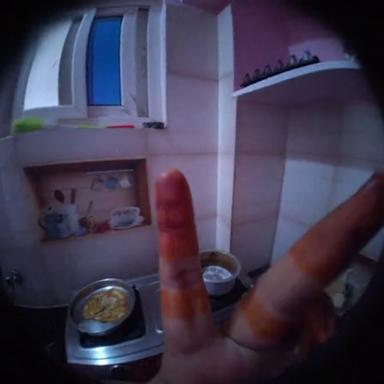

['### Analysis\nThe dialog turn references adjusting "camera glasses," which directly aligns with the egocentric, fisheye-distorted view in the frame (suggesting a wearable camera like glasses). The visible hand (with stained fingers, possibly from cooking ingredients) appears prominent and could be in the act of adjustment or gesturing near the face/eyes. In a cooking video context, this meta-question about the recording setup is slightly tangential to pure recipe steps but coherent for an instructional video where the user might pause to address technical aspects. Overall, it fits well as a natural interruption during hands-on cooking.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 4, "overall_coherence": 5}\n---']
['Analysis: The user is asking about adjusting their camera glasses, which is directly related to the first-person perspective of the video. The image shows a hand making a peace sign, which could be interpreted as the user interacting with their camera or g

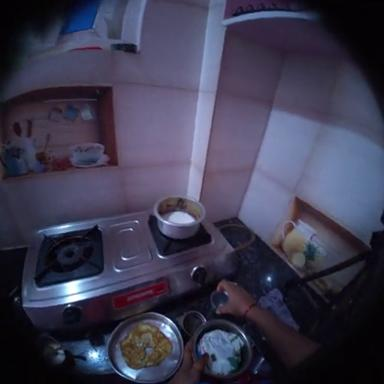

['### Analysis\nThe dialog turn instructs handling a "milk bowl" by switching hands and placing it on a shelf, which aligns with the egocentric view showing hands holding bowls (one with white contents that could represent milk or a similar liquid ingredient) near a kitchen shelf and stove setup. This suggests a step in managing ingredients during cooking, though the exact contents aren\'t definitively milk, making it somewhat interpretive but contextually fitting for a hands-on cooking scenario.\n\n---\n{"visual_relevance": 4, "contextual_appropriateness": 5, "overall_coherence": 4}']
['The user is holding a bowl in one hand and a plate in the other, standing over a stove. The assistant\'s instruction to "transfer the milk bowl to your other hand and place it back on the shelf" is relevant because the user is holding a bowl, and the instruction suggests an action to take with it. However, it\'s unclear if the bowl contains milk, and there isn\'t a visible "shelf" that the bowl would t

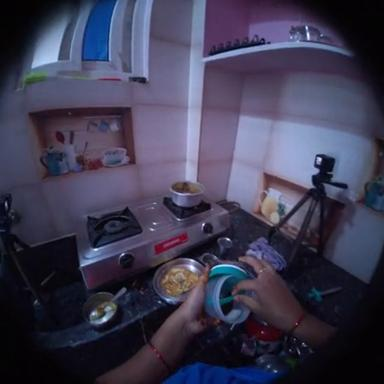

['### Analysis\nThe dialog turn instructs on handling a measuring spoon to scoop and pour tea leaves into a pot, which involves kitchen actions like scooping and pouring near a stovetop. The visual frame shows an egocentric view of hands using a green scoop/spoon near a stove with a pot and pan containing yellow material (likely food like spices or eggs, not tea leaves), plus utensils and shelves. The actions (scooping/pouring) loosely align with the hand movements and stove setup, but the specific content (tea leaves vs. apparent savory cooking elements) mismatches, reducing relevance and coherence in this cooking context.\n\n---\n{"visual_relevance": 3, "contextual_appropriateness": 2, "overall_coherence": 2}']
['The user is currently holding a container and a spoon, and there is a pot on the stovetop. The instructions to pick up a measuring spoon, scoop tea leaves, and pour them into the pot are highly relevant to the visual context and the ongoing cooking activity.\n\n---\n{"visual

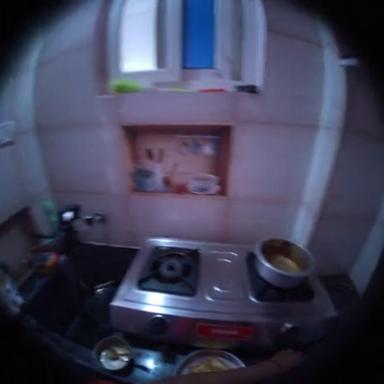

['### Analysis\nThe frame shows an egocentric view of a kitchen with a lit gas stove under a pot containing yellowish contents (possibly oil or spices), countertop space, and hands near small bowls or cups with yellow material, suggesting ongoing cooking prep. The dialog directly references the lit stove (visible flame) and countertop (for dropping lighter), which aligns well. The tea filter and its contents (likely the yellow material in the visible bowl/cup) relate to handling ingredients or waste in a cooking context, such as straining tea or spices. A waste bag isn\'t visible but fits as a logical next step for disposal. Overall, the turn is coherent for a step-by-step cooking guidance, though the waste bag introduces a minor unseen element.\n\n---\n{"visual_relevance": 4, "contextual_appropriateness": 5, "overall_coherence": 4}']
['The assistant\'s instructions about the stove being lit and dropping the lighter are relevant as a stove is visible. However, the subsequent instructio

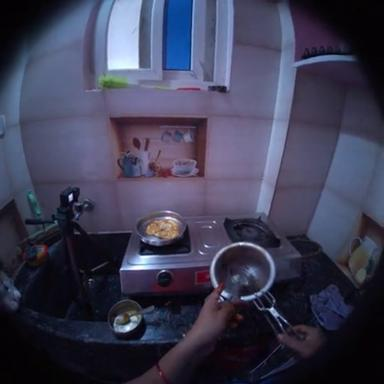

['### Analysis\nThe frame shows an egocentric view of a kitchen stove with a stainless steel pot and a frying pan containing food (possibly eggs). A hand is visibly holding a metal strainer (which could serve as a tea filter or infuser) near the stove area, positioned as if about to place or drop it. This directly aligns with the instruction to "drop the tea filter into the pot," suggesting an action like adding tea leaves or straining into the pot during cooking. The context fits a cooking scenario, though the presence of frying food introduces slight ambiguity about whether it\'s specifically tea preparation, but the core action (dropping a filter-like tool into a pot) is coherent and appropriate.\n\n---\n{"visual_relevance": 4, "contextual_appropriateness": 4, "overall_coherence": 4}\n---']
['The user is holding a tea filter over a pot, and the assistant\'s instruction to "Drop the tea filter into the pot" directly corresponds to this action.\n\n---\n{"visual_relevance": 5, "context

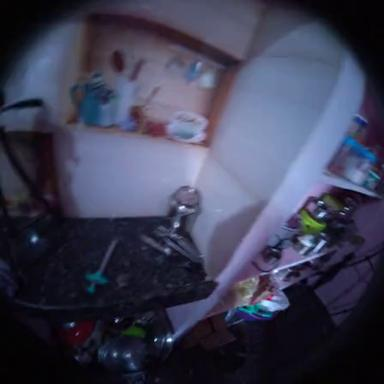

['### Analysis\nThe dialog turn introduces a milk tea recipe and instructs the user to grab a cup from the shelf and place it on the countertop, which aligns well with the egocentric kitchen view showing accessible shelves with cups/mugs, utensils, and a clear countertop area. This is a logical starting point for a beverage preparation in a visible cooking environment, with no mismatches in context or relevance.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['Analysis:\nThe assistant\'s turn is the opening of a cooking session. It introduces the task (making milk tea) and gives the first instruction. The visual context shows a kitchen setting with shelves and a countertop, which are relevant to the instruction "pick up a cup from the shelf and place it on the countertop." Although no cup is explicitly highlighted or being picked up at this exact moment, the environment supports the instruction.\n\n---\n{"visual_relevance": 4, "contextual_app

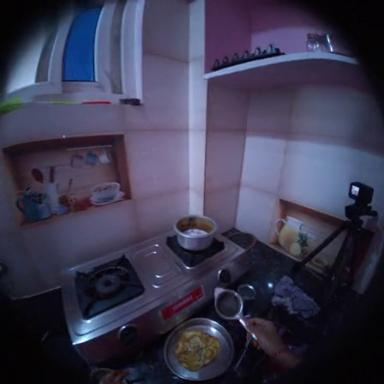

['### Analysis\nThe dialog turn instructs placing a tea filter back on a cup, which appears related to tea preparation. However, the visual frame depicts an active cooking scene on a stove with a pot, pan, and hand-held utensils (likely frying or cooking food like dosa), along with kitchen shelves but no prominent cup or tea filter in use. This creates a mismatch: the instruction does not align with the visible cooking activity, making it irrelevant and incoherent in context.\n\n---\n{"visual_relevance": 1, "contextual_appropriateness": 1, "overall_coherence": 1}']
['The user is holding a tea filter over a cup, and the assistant\'s instruction to "Place the tea filter back on the cup" directly relates to this action and the visible objects.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The user is holding a tea filter over a cup, and the assistant\'s instruction to "Place the tea filter back on the cup" directly relates to this action and 

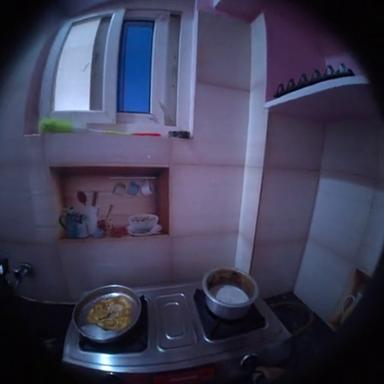

['### Analysis\nThe visual frame depicts an egocentric view of a kitchen stove area with a frying pan (possibly containing eggs or similar) on one burner and a pot (possibly rice) on the other, alongside countertop space, wall shelves with utensils, and a window. No cup is visibly present on the countertop or elsewhere in the frame. The dialog instructs picking up and placing down a cup, which relates loosely to the countertop but lacks direct visual evidence of the object or action, making it seem disconnected from the ongoing cooking activity on the stove. In a cooking context, this could be a minor preparatory step (e.g., clearing space), but it feels tangential and not actively tied to the visible cooking elements.\n\n---\n{"visual_relevance": 2, "contextual_appropriateness": 3, "overall_coherence": 2}']
['Analysis: The dialog turn instructs the user to pick up a cup and place it back down. In the visual frame, there are cups visible on a shelf above the countertop. While the instr

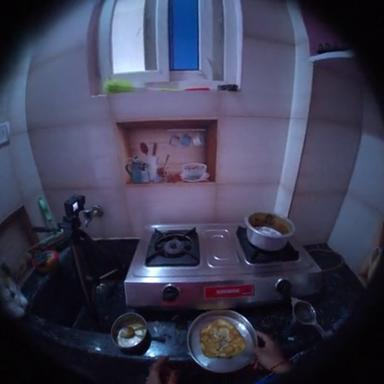

['### Analysis\nThe frame shows an egocentric view of a kitchen countertop with a visible plate containing yellowish food (likely an omelet) near the hands, adjacent to a stovetop with a pot on one burner. The instruction directly references picking up this visible plate from the countertop and moving it to the nearby stovetop, which aligns well with the scene. It\'s contextually appropriate for a cooking assistant guiding post-cooking actions (e.g., relocating food), though placing directly on a potentially hot stovetop could imply caution, but it fits the instructional flow. Overall, the turn is coherent and grounded in the visuals.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 4, "overall_coherence": 5}']
['The assistant\'s instruction to pick up the plate of omelet and place it on the stovetop is highly relevant and appropriate. The user is holding a plate with an omelet, and a stovetop is visible in the frame.\n\n---\n{"visual_relevance": 5, "contextual_appropriate

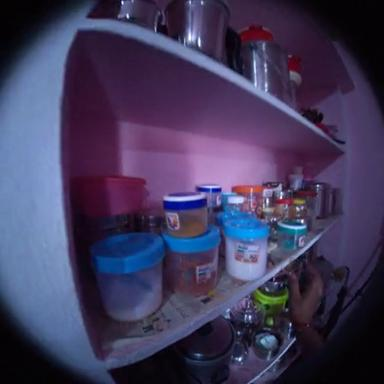

['### Analysis\nThe visual frame depicts a kitchen shelf stocked with various containers (jars, pots, and labeled spice/ingredient holders, including what appears to be powdered substances like sugar in white containers). A hand is visible reaching toward the shelf, aligning directly with the instruction to pick up and handle a sugar container. This is a clear cooking setup, making the dialog about adding sugar by retrieving it from the shelf highly appropriate and coherent for an egocentric cooking guidance scenario.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The dialog turn instructs the user to pick up a sugar container from the shelf and open it. The image shows a shelf with multiple containers, and a hand is visible near the bottom right, seemingly reaching for or interacting with one of the containers. This aligns well with the instruction to pick up a container from the shelf.\n\n---\n{"visual_relevance": 5, "contextual_appropria

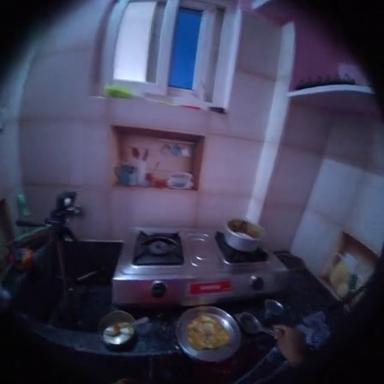

['### Analysis\nThe visual frame depicts an active cooking scene on a kitchen countertop and stove, with pots containing food (e.g., curry-like dish), utensils, and hands engaged in stirring or cooking. A countertop is visible, which loosely relates to picking up an item, but no tea filter or waste bag is apparent. The instruction involves tea preparation waste disposal, which feels mismatched to the ongoing meal cooking (e.g., no tea-related elements like kettles or filters are shown), reducing coherence in this specific frame.\n\n---\n{"visual_relevance": 2, "contextual_appropriateness": 3, "overall_coherence": 2}']
['The image shows a kitchen counter with a stove and some cooking items. While there\'s a plate with food, it\'s not clear if a tea filter or waste bag is present or relevant to the current activity. The instruction to pick up a tea filter and drop dirt into a waste bag doesn\'t seem to align with the visible items or an obvious cooking task in progress.\n\n---\n{"visual_

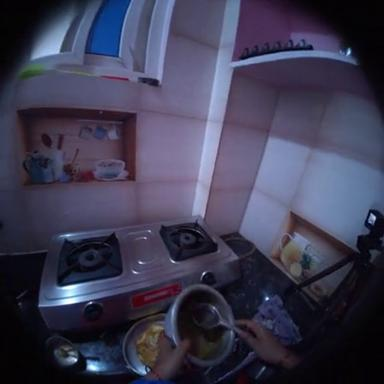

['The dialog turn provides instructions for tea preparation involving a tea filter, pot, and cup, but the visual frame depicts an egocentric view of cooking on a stovetop, with hands holding a pot containing yellow food (likely eggs or a similar dish) and a spoon, alongside a frying pan—none of which aligns with tea-making. The shared elements (pot and stovetop) are superficial and do not match the specific actions or context.\n\n---\n{"visual_relevance": 2, "contextual_appropriateness": 1, "overall_coherence": 1}\n---']
['The user is holding a pot with a spoon in it, and there\'s a stovetop visible. The assistant\'s instructions about picking up a tea filter from the pot and placing it on a cup, then placing the pot on the stovetop, are relevant to the items and actions that could be taking place in this kitchen setting. The pot is currently being held, and the stovetop is available.\n\n---\n{"visual_relevance": 4, "contextual_appropriateness": 4, "overall_coherence": 4}']
['The user 

In [23]:
# Run Strategy 1 Evaluation
MAX_DIALOGS = 3  # Adjust as needed
SAMPLE_FRACTION = 0.3

strategy1_results = []

print(f"Running Strategy 1: Visual-Turn Coherence Evaluation")
print(f"Evaluating {MAX_DIALOGS} dialogs with {SAMPLE_FRACTION:.0%} turn sampling\n")

for i, dialog_data in enumerate(generated_dialogs[:MAX_DIALOGS]):
    print(f"\n{'='*80}")
    print(f"Dialog {i+1}/{MAX_DIALOGS}")
    print(f"{'='*80}")
    
    # Extract video ID
    video_uid = dialog_data.get("video_uid")
    if not video_uid:
        print(f"  No video_uid found, skipping...")
        continue
    
    # Load frames
    take_name = dialog_data["parsed_video_anns"]["take_name"]
    arrow_file = find_arrow_file_for_video("/projects/beto/proassist_data/processed_data/egoexo4d/frames/", video_uid, take_name)
    frames_data = load_frames_from_arrow(arrow_file)
    if frames_data is None:
        print(f"  Could not load frames, skipping...")
        continue
    
    # Extract turns
    turns = extract_conversation_turns(dialog_data)
    if not turns:
        print(f"  No conversation turns found, skipping...")
        continue
    
    # Sample turns
    sampled_user, sampled_assistant = sample_turns(turns, SAMPLE_FRACTION)
    print(f"\nSampled {len(sampled_user)} user + {len(sampled_assistant)} assistant turns")
    
    dialog_results = {
        "dialog_id": i,
        "video_uid": video_uid,
        "user_turn_evaluations": [],
        "assistant_turn_evaluations": []
    }
    
    # Evaluate user turns
    print(f"\n{'─'*80}")
    print("USER TURNS")
    print(f"{'─'*80}")
    for turn_idx, turn in enumerate(sampled_user, 1):
        timestamp = turn.get("time")
        if timestamp is None:
            continue
        
        frame = get_frame_at_timestamp(frames_data, timestamp)
        if frame is None:
            continue
        
        print(f"\n[User Turn {turn_idx}] Time: {timestamp}s")
        print(f"Content: \"{turn.get('content', '')}\"")
        
        # Display frame
        from IPython.display import display
        display(frame)
        
        # Evaluate
        eval_result = evaluate_turn_with_frame(turn, frame, evaluators)
        dialog_results["user_turn_evaluations"].append(eval_result)
        
        # Display model scores
        print("\nModel Evaluations:")
        for model_name, scores in eval_result["model_scores"].items():
            if scores:
                print(f"  {model_name:8s}: VR={scores['visual_relevance']}, CA={scores['contextual_appropriateness']}, OC={scores['overall_coherence']}")
            else:
                print(f"  {model_name:8s}: Failed to parse")
        
        if eval_result["average_scores"]:
            avg = eval_result["average_scores"]
            print(f"\n  Average:  VR={avg['visual_relevance']:.2f}, CA={avg['contextual_appropriateness']:.2f}, OC={avg['overall_coherence']:.2f}")
    
    # Evaluate assistant turns
    print(f"\n{'─'*80}")
    print("ASSISTANT TURNS")
    print(f"{'─'*80}")
    for turn_idx, turn in enumerate(sampled_assistant, 1):
        timestamp = turn.get("time")
        if timestamp is None:
            continue
        
        frame = get_frame_at_timestamp(frames_data, timestamp)
        if frame is None:
            continue
        
        print(f"\n[Assistant Turn {turn_idx}] Time: {timestamp}s")
        print(f"Content: \"{turn.get('content', '')}\"")
        
        # Display frame
        display(frame)
        
        # Evaluate
        eval_result = evaluate_turn_with_frame(turn, frame, evaluators)
        dialog_results["assistant_turn_evaluations"].append(eval_result)
        
        # Display model scores
        print("\nModel Evaluations:")
        for model_name, scores in eval_result["model_scores"].items():
            if scores:
                print(f"  {model_name:8s}: VR={scores['visual_relevance']}, CA={scores['contextual_appropriateness']}, OC={scores['overall_coherence']}")
            else:
                print(f"  {model_name:8s}: Failed to parse")
        
        if eval_result["average_scores"]:
            avg = eval_result["average_scores"]
            print(f"\n  Average:  VR={avg['visual_relevance']:.2f}, CA={avg['contextual_appropriateness']:.2f}, OC={avg['overall_coherence']:.2f}")
    
    strategy1_results.append(dialog_results)
    print(f"\n{'='*80}")
    print(f"Dialog {i+1} Summary: {len(dialog_results['user_turn_evaluations'])} user, "
          f"{len(dialog_results['assistant_turn_evaluations'])} assistant evaluations completed")
    print(f"{'='*80}")

print(f"\n\n🎉 Strategy 1 completed: {len(strategy1_results)} dialogs evaluated")

## Strategy 2: Question-Answer Pair Evaluation (not really visual-based eval)

Find user questions and evaluate whether the assistant's response is appropriate. 

In [16]:
QA_EVALUATION_PROMPT = """You are evaluating question-answer pairs from a cooking assistant dialog. For each pair, assess the quality of the assistant's response to the user's question.

Question-Answer Pairs:
{qa_pairs_text}

For each Q&A pair, rate on a scale of 1-5:
1. **Answer Relevance**: Does the answer directly address the question?
2. **Answer Helpfulness**: Is the answer helpful and actionable?
3. **Answer Appropriateness**: Is the answer appropriate for the cooking context?

Scoring:
1 = Very poor
2 = Poor
3 = Acceptable
4 = Good
5 = Excellent

Provide brief analysis for each pair, then scores as a JSON array:
---
[
  {{"pair_id": 1, "relevance": x, "helpfulness": y, "appropriateness": z}},
  {{"pair_id": 2, "relevance": x, "helpfulness": y, "appropriateness": z}},
  ...
]"""


def evaluate_qa_pairs(
    qa_pairs: List[Tuple[Dict, Dict]],
    evaluators: Dict[str, OpenRouterGenerator]
) -> Dict[str, Any]:
    """Evaluate all Q&A pairs in one prompt"""
    
    if not qa_pairs:
        return None
    
    # Format Q&A pairs
    qa_text_parts = []
    for idx, (q_turn, a_turn) in enumerate(qa_pairs, 1):
        q_content = q_turn.get("content", "")
        a_content = a_turn.get("content", "")
        q_time = q_turn.get("time", "unknown")
        a_time = a_turn.get("time", "unknown")
        
        qa_text_parts.append(
            f"Pair {idx}:\n"
            f"  Q (t={q_time}s): {q_content}\n"
            f"  A (t={a_time}s): {a_content}"
        )
    
    qa_pairs_text = "\n\n".join(qa_text_parts)
    
    prompt_text = QA_EVALUATION_PROMPT.format(qa_pairs_text=qa_pairs_text)
    messages = [("user", prompt_text)]
    
    # Evaluate with each model
    model_scores = {}
    for model_name, evaluator in evaluators.items():
        try:
            response = evaluator.generate(messages, temperature=0.3, max_tokens=1024)
            
            # Parse array of scores
            response_text = response[0]
            if "---" in response_text:
                response_text = response_text.split("---", 1)[1]
            
            # Extract JSON array
            json_match = re.search(r'\[.*\]', response_text, re.DOTALL)
            if json_match:
                scores_array = json.loads(json_match.group())
                model_scores[model_name] = scores_array
            else:
                model_scores[model_name] = None
            
            time.sleep(1)
        except Exception as e:
            print(f"Error with {model_name}: {e}")
            model_scores[model_name] = None
    
    # Calculate average scores per pair
    avg_scores_per_pair = []
    for pair_idx in range(len(qa_pairs)):
        pair_scores = []
        for model_name, scores_array in model_scores.items():
            if scores_array and pair_idx < len(scores_array):
                pair_scores.append(scores_array[pair_idx])
        
        if pair_scores:
            avg_scores = {
                "pair_id": pair_idx + 1,
                "relevance": np.mean([s.get("relevance", 0) for s in pair_scores if "relevance" in s]),
                "helpfulness": np.mean([s.get("helpfulness", 0) for s in pair_scores if "helpfulness" in s]),
                "appropriateness": np.mean([s.get("appropriateness", 0) for s in pair_scores if "appropriateness" in s])
            }
            avg_scores_per_pair.append(avg_scores)
    
    return {
        "model_scores": model_scores,
        "average_scores": avg_scores_per_pair
    }


print("Strategy 2 evaluation function defined!")

Strategy 2 evaluation function defined!


In [17]:
# Run Strategy 2 Evaluation
strategy2_results = []

print(f"Running Strategy 2: Question-Answer Pair Evaluation")
print(f"Evaluating {MAX_DIALOGS} dialogs\n")

for i, dialog_data in enumerate(generated_dialogs[:MAX_DIALOGS]):
    print(f"Dialog {i+1}/{MAX_DIALOGS}")
    
    video_uid = dialog_data.get("video_uid")
    turns = extract_conversation_turns(dialog_data)
    
    if not turns:
        print(f"  No conversation turns found, skipping...")
        continue
    
    # Find Q&A pairs
    qa_pairs = find_question_answer_pairs(turns)
    print(f"  Found {len(qa_pairs)} question-answer pairs")
    
    if not qa_pairs:
        print(f"  No Q&A pairs found, skipping...\n")
        continue
    
    # Evaluate all pairs together
    eval_result = evaluate_qa_pairs(qa_pairs, evaluators)
    
    strategy2_results.append({
        "dialog_id": i,
        "video_uid": video_uid,
        "num_qa_pairs": len(qa_pairs),
        "qa_pairs": qa_pairs,
        "evaluation": eval_result
    })
    
    print(f"  Completed evaluation of {len(qa_pairs)} Q&A pairs\n")

print(f"Strategy 2 completed: {len(strategy2_results)} dialogs evaluated")

Running Strategy 2: Question-Answer Pair Evaluation
Evaluating 3 dialogs

Dialog 1/3
  Found 3 question-answer pairs
  Completed evaluation of 3 Q&A pairs

Strategy 2 completed: 1 dialogs evaluated
  Completed evaluation of 3 Q&A pairs

Strategy 2 completed: 1 dialogs evaluated


## Results Summary

In [18]:
print("="*80)
print("EVALUATION RESULTS SUMMARY")
print("="*80)

# Strategy 1 Summary
print("\n📊 STRATEGY 1: Visual-Turn Coherence Evaluation")
print("-" * 60)

all_user_scores = []
all_assistant_scores = []

for result in strategy1_results:
    for eval_res in result["user_turn_evaluations"]:
        if eval_res["average_scores"]:
            all_user_scores.append(eval_res["average_scores"])
    
    for eval_res in result["assistant_turn_evaluations"]:
        if eval_res["average_scores"]:
            all_assistant_scores.append(eval_res["average_scores"])

if all_user_scores:
    print(f"\nUser Turns ({len(all_user_scores)} evaluated):")
    for field in ["visual_relevance", "contextual_appropriateness", "overall_coherence"]:
        scores = [s[field] for s in all_user_scores]
        print(f"  {field}: {np.mean(scores):.2f} ± {np.std(scores):.2f}")

if all_assistant_scores:
    print(f"\nAssistant Turns ({len(all_assistant_scores)} evaluated):")
    for field in ["visual_relevance", "contextual_appropriateness", "overall_coherence"]:
        scores = [s[field] for s in all_assistant_scores]
        print(f"  {field}: {np.mean(scores):.2f} ± {np.std(scores):.2f}")

# Strategy 2 Summary
print("\n\n📊 STRATEGY 2: Question-Answer Pair Evaluation")
print("-" * 60)

all_qa_scores = []
for result in strategy2_results:
    if result["evaluation"] and result["evaluation"]["average_scores"]:
        all_qa_scores.extend(result["evaluation"]["average_scores"])

if all_qa_scores:
    print(f"\nQ&A Pairs ({len(all_qa_scores)} evaluated):")
    for field in ["relevance", "helpfulness", "appropriateness"]:
        scores = [s[field] for s in all_qa_scores if field in s]
        if scores:
            print(f"  {field}: {np.mean(scores):.2f} ± {np.std(scores):.2f}")

# Save results
timestamp = time.strftime("%Y%m%d_%H%M%S")
results_file = f"visual_dialog_evaluation_{timestamp}.json"

save_data = {
    "metadata": {
        "timestamp": timestamp,
        "num_dialogs": MAX_DIALOGS,
        "sample_fraction": SAMPLE_FRACTION,
        "models": list(evaluators.keys())
    },
    "strategy1_results": strategy1_results,
    "strategy2_results": strategy2_results
}

with open(results_file, "w") as f:
    json.dump(save_data, f, indent=2)

print(f"\n\n💾 Results saved to: {results_file}")

EVALUATION RESULTS SUMMARY

📊 STRATEGY 1: Visual-Turn Coherence Evaluation
------------------------------------------------------------

User Turns (1 evaluated):
  visual_relevance: 3.67 ± 0.00
  contextual_appropriateness: 3.00 ± 0.00
  overall_coherence: 3.33 ± 0.00

Assistant Turns (11 evaluated):
  visual_relevance: 3.44 ± 1.16
  contextual_appropriateness: 3.61 ± 0.98
  overall_coherence: 3.50 ± 1.01


📊 STRATEGY 2: Question-Answer Pair Evaluation
------------------------------------------------------------

Q&A Pairs (3 evaluated):
  relevance: 4.56 ± 0.63
  helpfulness: 3.89 ± 0.42
  appropriateness: 4.44 ± 0.57


💾 Results saved to: visual_dialog_evaluation_20251013_071155.json


## Future Evaluation Strategies

Here are additional evaluation strategies to consider for future work:

### 1. **Temporal Consistency Evaluation**
- Track key objects/ingredients mentioned across multiple turns
- Verify that visual evidence shows consistent state changes (e.g., if assistant says "the onions are now golden", check frames before and after)
- Score temporal coherence between dialog progression and visual progression

### 2. **Action-Grounding Evaluation**
- When assistant gives instructions (e.g., "stir the sauce"), check if the relevant objects are visible in nearby frames
- Evaluate whether action suggestions are grounded in visible affordances (tools, ingredients available)
- Compare frames before/after action instructions to verify feasibility

### 3. **Multi-Frame Context Evaluation**
- Instead of single frames, use sliding windows of 3-5 frames around each turn
- Evaluate whether the dialog captures the dynamics of the cooking process
- Check if assistant anticipates next steps based on visual trajectory

### 4. **Error Detection Evaluation**
- Specifically look for contradictions between visual evidence and dialog content
- Score how often the assistant makes claims not supported by frames (hallucinations)
- Evaluate the assistant's ability to correct user misconceptions based on visual evidence

### 5. **Proactive Assistance Evaluation**
- Identify moments where the assistant proactively offers help before being asked
- Check if these proactive suggestions are visually justified (e.g., warning about boiling over)
- Score the appropriateness and timeliness of proactive interventions

### 6. **Safety and Correctness Evaluation**
- Evaluate safety-related warnings (hot surfaces, sharp objects) against visual evidence
- Check cooking technique correctness (temperature, timing) when visible in frames
- Score whether the assistant catches potential safety issues visible in frames

### 7. **Cross-Modal Alignment Evaluation**
- Measure semantic similarity between frame descriptions (from vision model) and dialog content
- Evaluate whether technical cooking terms align with visual states
- Check if quantity/measurement references match visible portions

### 8. **User Intent Understanding Evaluation**
- For ambiguous user questions, evaluate if assistant's interpretation matches visual context
- Score how well the assistant disambiguates based on what's visible
- Evaluate clarifying questions against visual evidence

### 9. **Dialog Flow Quality with Visual Anchoring**
- Evaluate natural transition between topics as reflected in frame changes
- Score whether topic shifts align with visual scene changes
- Check if the assistant maintains context across different cooking stages (visible in frames)

### 10. **Comparative Evaluation with Human Annotations**
- If available, compare LLM-generated responses to human expert annotations
- Use frames to identify where LLM diverges from human judgment
- Score alignment with human-labeled key moments in the video